In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration for clean output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Project paths (using pathlib – cross-platform safe)
ROOT = Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"

# Create folders if they don't exist
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Project paths configured successfully.")

Project paths configured successfully.


In [2]:
file_path = "data/raw/Data_set.csv" 

df = pd.read_csv(file_path)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
print("First 5 rows:")
df.head()

Shape: 5,751 rows × 7 columns
Columns: ['Country Name', 'Year', 'Employment Sector: Agriculture', 'Employment Sector: Industry', 'Employment Sector: Services', 'Unemployment Rate', 'GDP (in USD)']
First 5 rows:


,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
0,Albania,1991,53.300,12.173,34.528,10.304,1099559028.000
1,Algeria,1991,24.119,25.068,50.814,20.600,45715676428.000
2,Angola,1991,40.072,8.163,51.765,16.855,10603784541.000
3,Argentina,1991,13.670,28.506,57.824,5.440,189720000000.000
4,Armenia,1991,54.263,15.790,29.946,1.783,2069870130.000


In [3]:
#create a new and clean dataframe for change the decimal and other
df_clean = df.copy() # so we use df_clean right now

# Round for readability
df_clean['Unemployment Rate'] = df_clean['Unemployment Rate'].round(2)
df_clean['Employment Sector: Agriculture'] = df_clean['Employment Sector: Agriculture'].round(1)
df_clean['Employment Sector: Industry'] = df_clean['Employment Sector: Industry'].round(1)
df_clean['Employment Sector: Services'] = df_clean['Employment Sector: Services'].round(1)

# add a new column for GDP in billion USD for better readability
df_clean['GDP (billion USD)'] = (df_clean['GDP (in USD)'] / 1_000_000_000).round(2)

# Drop original GDP column since we have the new one which is = GDP(billion USD)  above one
df_clean = df_clean.drop(columns=['GDP (in USD)'])

df_clean.head()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD)
0,Albania,1991,53.300,12.200,34.500,10.300,1.100
1,Algeria,1991,24.100,25.100,50.800,20.600,45.720
2,Angola,1991,40.100,8.200,51.800,16.860,10.600
3,Argentina,1991,13.700,28.500,57.800,5.440,189.720
4,Armenia,1991,54.300,15.800,29.900,1.780,2.070


In [4]:
#create a new one df for Malaysia only
df_malaysia = df_clean[df_clean['Country Name'] == 'Malaysia'].copy()

df_malaysia['covid_period'] = (df_malaysia['Year'] >= 2020).astype(int)
df_malaysia.tail()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD),covid_period
4957,Malaysia,2018,10.600,27.600,61.700,3.300,358.790,0
5137,Malaysia,2019,10.200,27.700,62.000,3.260,365.180,0
5316,Malaysia,2020,10.500,27.800,61.700,4.540,337.460,1
5494,Malaysia,2021,10.300,28.200,61.500,4.640,373.780,1
5672,Malaysia,2022,10.000,28.100,61.900,3.930,407.610,1


In [5]:
df_malaysia['unemp_change_pct'] = df_malaysia['Unemployment Rate'].diff().round(2)
df_malaysia.head()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD),covid_period,unemp_change_pct
94,Malaysia,1991,18.900,31.400,49.700,3.700,49.140,0,NaN
267,Malaysia,1992,18.500,31.600,49.900,3.710,59.170,0,0.010
441,Malaysia,1993,17.800,32.000,50.200,4.110,66.890,0,0.400
615,Malaysia,1994,17.500,32.200,50.300,3.640,74.480,0,-0.470
792,Malaysia,1995,17.200,32.300,50.500,3.150,88.710,0,-0.490


In [6]:
display(df_malaysia[['Year','unemp_change_pct','covid_period']])
summary = df_malaysia.groupby('covid_period').agg({
    'Unemployment Rate': ['mean', 'min', 'max', 'std'],
    'unemp_change_pct' : ['mean','max','min']
})
print(summary)

,Year,unemp_change_pct,covid_period
94,1991,NaN,0
267,1992,0.010,0
441,1993,0.400,0
615,1994,-0.470,0
792,1995,-0.490,0
970,1996,-0.630,0
1148,1997,-0.070,0
1327,1998,0.750,0
1506,1999,0.230,0
1686,2000,-0.430,0


             Unemployment Rate                   unemp_change_pct             
                          mean   min   max   std             mean   max    min
covid_period                                                                  
0                        3.318 2.450 4.110 0.347           -0.016 0.750 -0.630
1                        4.370 3.930 4.640 0.384            0.223 1.280 -0.710


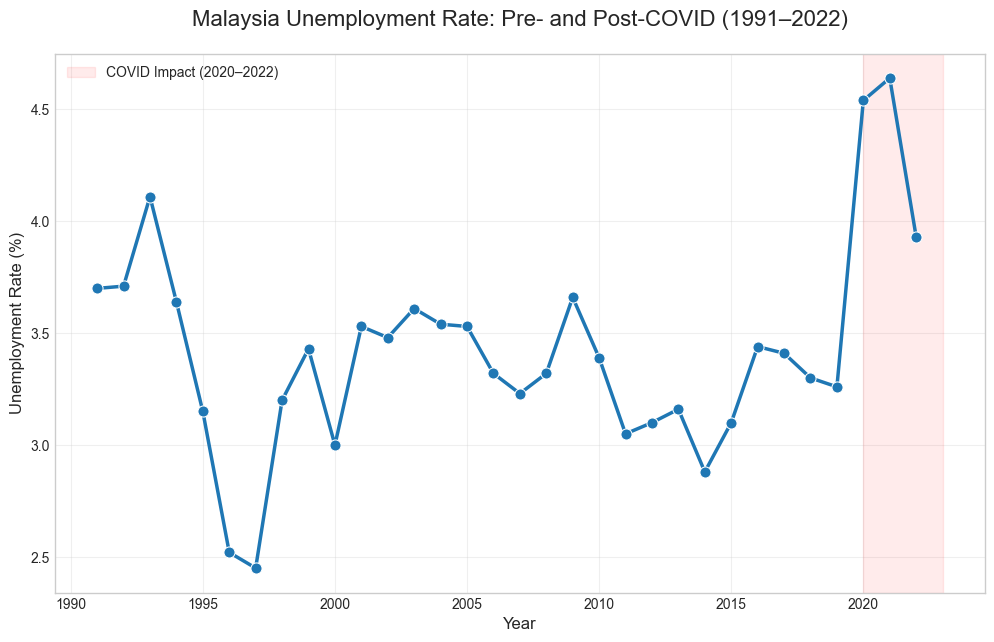

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=df_malaysia,
    x='Year',
    y='Unemployment Rate',
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize=8,
    ax=ax
)

# Shade COVID period
ax.axvspan(2020, 2023, color='red', alpha=0.08, label='COVID Impact (2020–2022)')

ax.set_title('Malaysia Unemployment Rate: Pre- and Post-COVID (1991–2022)', fontsize=16, pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Save for README or report
plt.savefig("images_chart/malaysia_unemployment_trend.png", dpi=300, bbox_inches='tight')

plt.show()

In [8]:
pre_avg = df_malaysia[df_malaysia['covid_period'] == 0]['Unemployment Rate'].mean().round(2)
post_avg = df_malaysia[df_malaysia['covid_period'] == 1]['Unemployment Rate'].mean().round(2)

print("Key Insights:")
print(f"Pre-COVID average unemployment rate in Malaysia: {pre_avg}%")
print(f"Post-COVID average unemployment rate in Malaysia: {post_avg}%")
print(f"Change: {(post_avg - pre_avg):.2f} percentage points")
print("Unemployment increased noticeably after 2020 due to pandemic lockdowns and economic disruption.")
print("Recovery appears underway by 2022, but volatility remains higher than pre-COVID levels.")
print("Compared to regional peers, Malaysia's labour market resilience is relatively strong.")

Key Insights:
Pre-COVID average unemployment rate in Malaysia: 3.32%
Post-COVID average unemployment rate in Malaysia: 4.37%
Change: 1.05 percentage points
Unemployment increased noticeably after 2020 due to pandemic lockdowns and economic disruption.
Recovery appears underway by 2022, but volatility remains higher than pre-COVID levels.
Compared to regional peers, Malaysia's labour market resilience is relatively strong.
